# Análisis de Productos y Ventas

Análisis de `products` (catálogo) y `order_items` (líneas de venta): categorías, precios, márgenes y top ventas.

Los datos se cargan desde la carpeta `Data/Raw/` del repositorio para que el trabajo sea reproducible por todo el equipo, sin depender de una descarga externa (kagglehub).

## 1. Carga de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 140)

DATA_DIR = 'Data/Raw'

# Solo se cargan los datasets que usa este análisis (catálogo y líneas de venta).
# customers, events, orders, reviews y sessions no se usan aquí y no se cargan.
products = pd.read_csv(f'{DATA_DIR}/products.csv')
order_items = pd.read_csv(f'{DATA_DIR}/order_items.csv')

products.head()

,product_id,category,name,price_usd,cost_usd,margin_usd
0,1,Electronics,SSD MediumBlue 149,570.28,352.69,217.59
1,2,Electronics,Keyboard DeepPink 696,498.13,263.13,235.00
2,3,Electronics,Headphones Orchid 188,548.53,309.60,238.93
3,4,Electronics,Smartwatch BurlyWood 664,268.36,153.56,114.80
4,5,Electronics,Smartwatch Cornsilk 328,63.69,42.65,21.04


## 2. Análisis de precios

In [2]:
# Margen en % por producto (se usa en las secciones siguientes)
products['margin_pct'] = products['margin_usd'] / products['price_usd'] * 100

print("Productos por categoría:")
print(products['category'].value_counts())

Productos por categoría:
category
Electronics       171
Home & Kitchen    171
Beauty            171
Sports            171
Fashion           171
Books             171
Toys              171
Name: count, dtype: int64


### Precios por categoría

                count        mean    min     max
category                                        
Electronics       171  315.573450  30.13  596.62
Sports            171  154.192573   9.97  299.44
Home & Kitchen    171  125.179064  10.91  249.07
Fashion           171  109.852222   9.69  199.64
Beauty            171   64.656550   5.50  119.56
Toys              171   43.879532   6.51   79.83
Books             171   26.212807   3.50   49.97


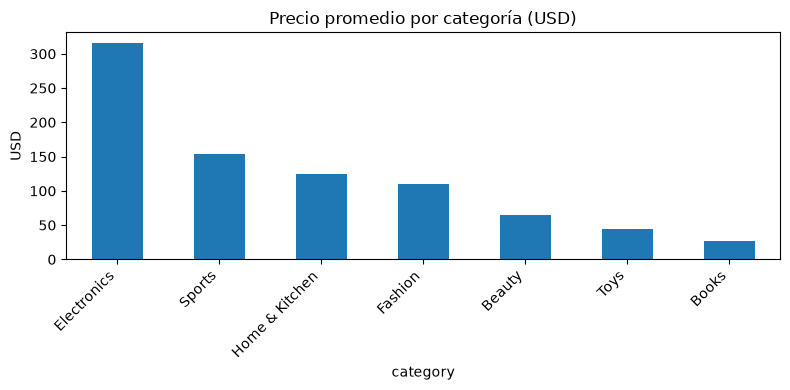

In [3]:
price_by_cat = products.groupby('category')['price_usd'].agg(['count', 'mean', 'min', 'max']).sort_values('mean', ascending=False)
print(price_by_cat)

price_by_cat['mean'].plot(kind='bar', figsize=(8, 4), title='Precio promedio por categoría (USD)')
plt.ylabel('USD')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Hallazgos:** `Electronics` es, por lejos, la categoría más cara (precio promedio ≈ USD 316, con productos de hasta USD 597), más del doble que la siguiente (`Sports`, ≈ USD 154). `Books` es la más económica (≈ USD 26 en promedio). Además, el catálogo está perfectamente balanceado: 171 productos por categoría, por lo que las diferencias de precio no responden a un sesgo de muestreo.

**Impacto:** al comparar categorías en ingresos o unidades vendidas hay que tener presente esta brecha de precio, ya que una categoría puede vender pocas unidades y aun así generar mucho ingreso (o viceversa).

## 3. Márgenes

                margin_usd_mean  margin_pct_mean
category                                        
Electronics          113.997018        36.709541
Home & Kitchen        44.557778        35.742613
Beauty                23.153567        35.346109
Books                  9.249649        35.283160
Sports                52.232982        34.816398
Fashion               37.846023        34.576746
Toys                  15.123801        34.033852

Margen global:
  Precio promedio: $119.94
  Costo promedio:  $77.63
  Margen promedio: $42.31 (35.22%)


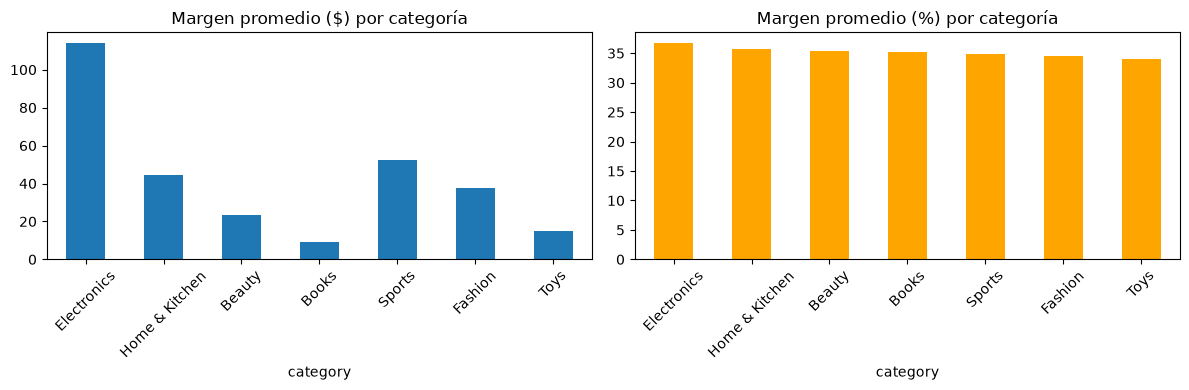

In [4]:
margin_by_cat = products.groupby('category').agg(
    margin_usd_mean=('margin_usd', 'mean'),
    margin_pct_mean=('margin_pct', 'mean')
).sort_values('margin_pct_mean', ascending=False)
print(margin_by_cat)

print()
print("Margen global:")
print(f"  Precio promedio: ${products['price_usd'].mean():.2f}")
print(f"  Costo promedio:  ${products['cost_usd'].mean():.2f}")
print(f"  Margen promedio: ${products['margin_usd'].mean():.2f} ({products['margin_pct'].mean():.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
margin_by_cat['margin_usd_mean'].plot(kind='bar', ax=axes[0], title='Margen promedio ($) por categoría')
margin_by_cat['margin_pct_mean'].plot(kind='bar', ax=axes[1], title='Margen promedio (%) por categoría', color='orange')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Hallazgos:** el margen porcentual es muy parejo entre categorías (entre 34% y 37%, contra un promedio global de 35.2%), lo que sugiere una política de pricing consistente (markup similar sobre el costo) más allá del rubro. En cambio, el margen en dólares sí varía fuerte: `Electronics` deja ≈ USD 114 por unidad vendida, casi el triple que `Sports` (≈ USD 52), simplemente porque parte de una base de precio más alta.

**Impacto:** para decisiones de rentabilidad conviene mirar el margen en dólares (no solo el %), porque con un markup similar, las categorías de precio alto son las que más aportan margen absoluto por unidad.

## 4. Top ventas

### Top ventas (uniendo `order_items` con `products`)

Top 10 por unidades vendidas:
 product_id                            name       category  qty  revenue
        496          Lipstick LightBlue 766         Beauty  179  1553.72
        442          Lipstick RosyBrown 771         Beauty  167  1055.44
        926                 E-book Gray 372          Books  160   961.60
        404  Conditioner CornflowerBlue 855         Beauty  159  1198.86
        265           Vacuum LightCoral 663 Home & Kitchen  157  5389.81
       1063 Action Figure DarkTurquoise 818           Toys  153  1914.03
       1170              Doll LightCyan 982           Toys  151  2793.50
        944            E-book PeachPuff 118          Books  151  2865.98
       1087    Building Blocks DarkCyan 517           Toys  150  1186.50
       1028               Puzzle Orchid 600           Toys  150  1068.00


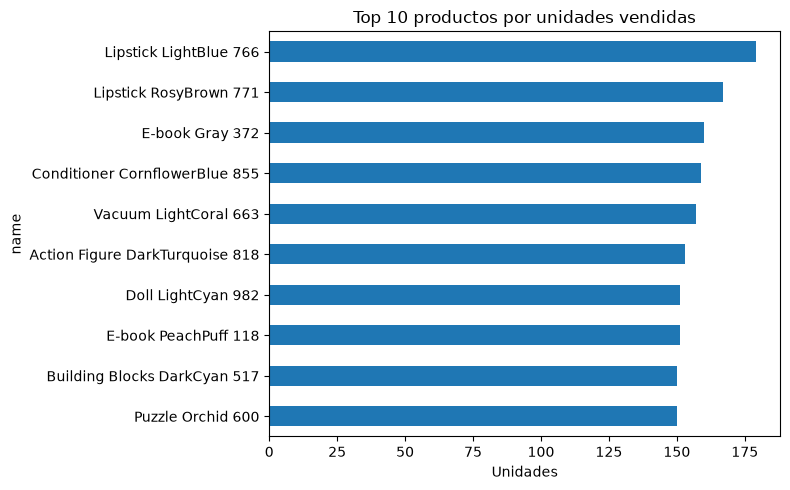

In [5]:
sales = order_items.groupby('product_id').agg(
    qty=('quantity', 'sum'),
    revenue=('line_total_usd', 'sum')
).reset_index()
sales = sales.merge(products, on='product_id')
sales['total_margin'] = sales['margin_usd'] * sales['qty']

top_qty = sales.sort_values('qty', ascending=False).head(10)
print("Top 10 por unidades vendidas:")
print(top_qty[['product_id', 'name', 'category', 'qty', 'revenue']].to_string(index=False))

top_qty.set_index('name')['qty'].plot(kind='barh', figsize=(8, 5), title='Top 10 productos por unidades vendidas')
plt.xlabel('Unidades')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Hallazgos:** el top 10 por unidades está dominado por productos de `Beauty`, `Books` y `Toys` (categorías de precio bajo), con volúmenes entre 150 y 179 unidades. Ningún producto de `Electronics` aparece en este ranking.

**Impacto:** el volumen de ventas por sí solo no es un buen indicador de qué productos priorizar comercialmente, ya que favorece a los ítems más baratos sin reflejar su aporte real en ingresos o margen.

Top 10 por ingresos:
 product_id                         name    category  qty  revenue
        104          Mouse RosyBrown 419 Electronics   55  9860.40
        120    Headphones Aquamarine 465 Electronics   16  9286.88
         51         Webcam LightBlue 848 Electronics   64  9212.80
          9         Mouse Chartreuse 292 Electronics  101  8962.74
        801    Hoodie BlanchedAlmond 225     Fashion   64  8874.24
        680  Tennis Racket PaleGreen 443      Sports   71  8778.44
        533 Cycling Helmet DarkKhaki 165      Sports   58  8709.28
        156      Smartwatch Moccasin 101 Electronics   41  8616.56
        657        Water Bottle Gold 746      Sports   45  8284.95
         87    Mouse MediumTurquoise 578 Electronics   47  8190.69


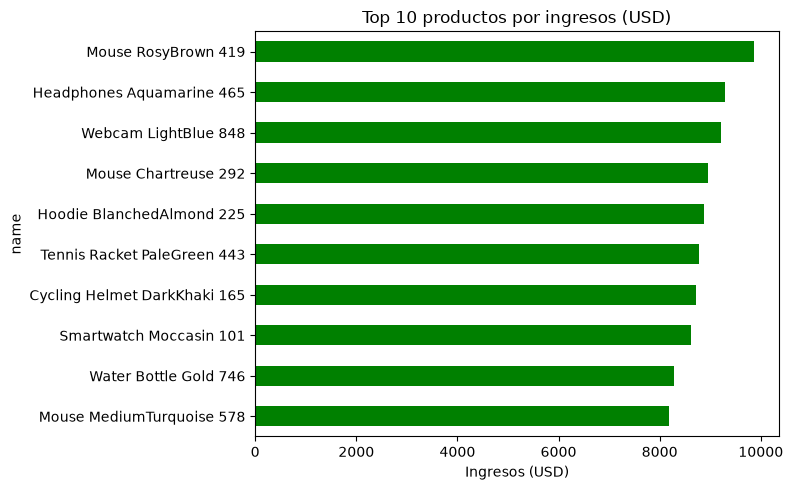

In [6]:
top_rev = sales.sort_values('revenue', ascending=False).head(10)
print("Top 10 por ingresos:")
print(top_rev[['product_id', 'name', 'category', 'qty', 'revenue']].to_string(index=False))

top_rev.set_index('name')['revenue'].plot(kind='barh', figsize=(8, 5), title='Top 10 productos por ingresos (USD)', color='green')
plt.xlabel('Ingresos (USD)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Hallazgos:** el ranking por ingresos es casi opuesto al de unidades: lo dominan `Electronics` y `Sports` (6 de los 10 puestos), con productos que venden relativamente pocas unidades (16 a 101) pero a precio alto, generando entre USD 8,200 y USD 9,860 cada uno.

**Impacto:** confirma que volumen e ingreso son señales distintas y potencialmente contradictorias; una estrategia de catálogo o de stock debería mirar ambos rankings (y el de margen) antes de decidir qué productos priorizar.

### Ventas e ingresos totales por categoría

                unidades   ingresos  margen_total
category                                         
Home & Kitchen      9461  840736.82     300634.79
Sports              8358  832349.63     293094.57
Fashion            10056  824739.33     287422.69
Electronics         4496  692866.07     257397.74
Beauty             13330  692312.49     245640.74
Toys               14875  569153.08     193954.48
Books              16530  383450.80     135152.65


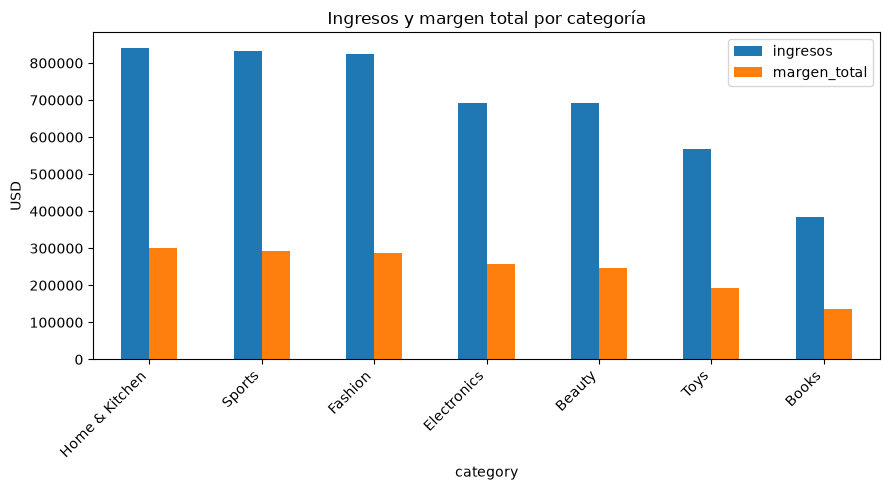

In [7]:
cat_summary = sales.groupby('category').agg(
    unidades=('qty', 'sum'),
    ingresos=('revenue', 'sum'),
    margen_total=('total_margin', 'sum')
).sort_values('ingresos', ascending=False)
print(cat_summary)

cat_summary[['ingresos', 'margen_total']].plot(kind='bar', figsize=(9, 5), title='Ingresos y margen total por categoría')
plt.ylabel('USD')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Hallazgos:** `Home & Kitchen` lidera en ingresos totales (≈ USD 841k) y margen total (≈ USD 301k) pese a no ser la categoría más vendida en unidades. En el otro extremo, `Books` vende más unidades que nadie (16,530) pero genera el menor ingreso total (≈ USD 383k) por su precio bajo. `Electronics`, con el precio y margen % más altos, queda en el medio de la tabla en ingresos totales porque vende relativamente pocas unidades (4,496, la menor cantidad de todas las categorías).

**Impacto:** a nivel categoría, el ingreso total depende tanto del precio como del volumen, y ninguna categoría domina en ambos ejes a la vez. Esto es clave para priorizar inventario y foco comercial: maximizar solo precio (`Electronics`) o solo volumen (`Books`) no maximiza el ingreso total.

## 5. Conclusiones

- **Precio:** `Electronics` es la categoría más cara con amplio margen sobre el resto; `Books` es la más económica. El catálogo está balanceado (171 productos por categoría).
- **Margen:** el markup porcentual es homogéneo entre categorías (34%-37%), pero el margen en dólares por unidad varía mucho y favorece a las categorías de precio alto (`Electronics`).
- **Top ventas:** el ranking por unidades y el ranking por ingresos son casi opuestos — `Beauty`/`Books`/`Toys` lideran en volumen, `Electronics`/`Sports` lideran en ingresos por producto.
- **Por categoría:** `Home & Kitchen` es la categoría más fuerte en ingresos y margen total; `Books` lidera en unidades pero no en ingresos; `Electronics` tiene el mejor margen % pero el menor volumen.
- **Recomendación:** cualquier decisión de catálogo, stock o foco comercial debería considerar precio, margen y volumen en conjunto, no una sola métrica aislada.